# Estudio del bandido de k-brazos mediante el algoritmo $\epsilon$-Greedy con distribución normal

En este notebook se ejecuta y comenta la ejecución del experimento del bandido de k-brazos mediante el algoritmo $\epsilon$-greedy con brazos cuya recompensa viene dada por una función de distribución normal.

## Constantes

In [1]:
SEED = 42

K = 10
RUNS = 1000
STEPS = 20_000

SAVE_PLOTS_PATH = "plots/epsilon_greedy_normal_dist"

## Librerías

In [2]:
import sys
import random

import numpy as np
from typing import List

sys.path.append('./src')
print(sys.path)

from arms import ArmNormal, Bandit
from experiment import run_experiment
from algorithms import Algorithm, EpsilonGreedy
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

['C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\python312.zip', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\DLLs', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none', 'C:\\Users\\Usuario\\Documents\\UM-MIA\\EML\\dourado-minguell-eml-mia-um-p1\\.venv', '', 'C:\\Users\\Usuario\\Documents\\UM-MIA\\EML\\dourado-minguell-eml-mia-um-p1\\.venv\\Lib\\site-packages', './src']


## Reproducibilidad

In [3]:
random.seed(SEED)
np.random.seed(SEED)

Asegurar que la generación de números aleatorios es igual para todos los experimentos.

## Experimentación

Se ejecuta la experimentación del problema del bandido de k-brazos durante el número de pasos y ejecuciones definido en las constantes. Posteriormente, se realiza el pertienente estudio de resultados mediantes las gráficas de recompensas promedio, selecciones óptimas, arrepentimiento y estadísticas por brazo.

In [4]:
# Creación del bandido de k-brazos
bandit = Bandit(arms=ArmNormal.generate_arms(K))
optimal_arm = bandit.optimal_arm

print(bandit)
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


Para le experimentación, se va emplear un bandido de 10 brazos. Para este caso reproducible, el brazo óptimo es el número 8 con una recompensa media esperada de 9.56. Se van a comparar los resultados con distintos valores para epsilon:
 - $\epsilon = 0.0$
 - $\epsilon = 0.01$
 - $\epsilon = 0.1$
 - $\epsilon = 0.5$

In [5]:
# Definir los algoritmos greedy con diferente epsilon
algorithms_greedy = [
    EpsilonGreedy(k=K, epsilon=0),
    EpsilonGreedy(k=K, epsilon=0.01),
    EpsilonGreedy(k=K, epsilon=0.1),
    EpsilonGreedy(k=K, epsilon=0.5)
]

# Ejecutar el experimento
rewards_greedy, optimal_selections_greedy, regret_accumulated_greedy, arm_stats_greedy = run_experiment(bandit, algorithms_greedy, STEPS, RUNS)

Ya se han definido los algoritmos y ejecutada la experimentación. A continuación, se van a comentar los resultados obetnidos mediante las correspondientes gráficas.

#### Recompensas promedio

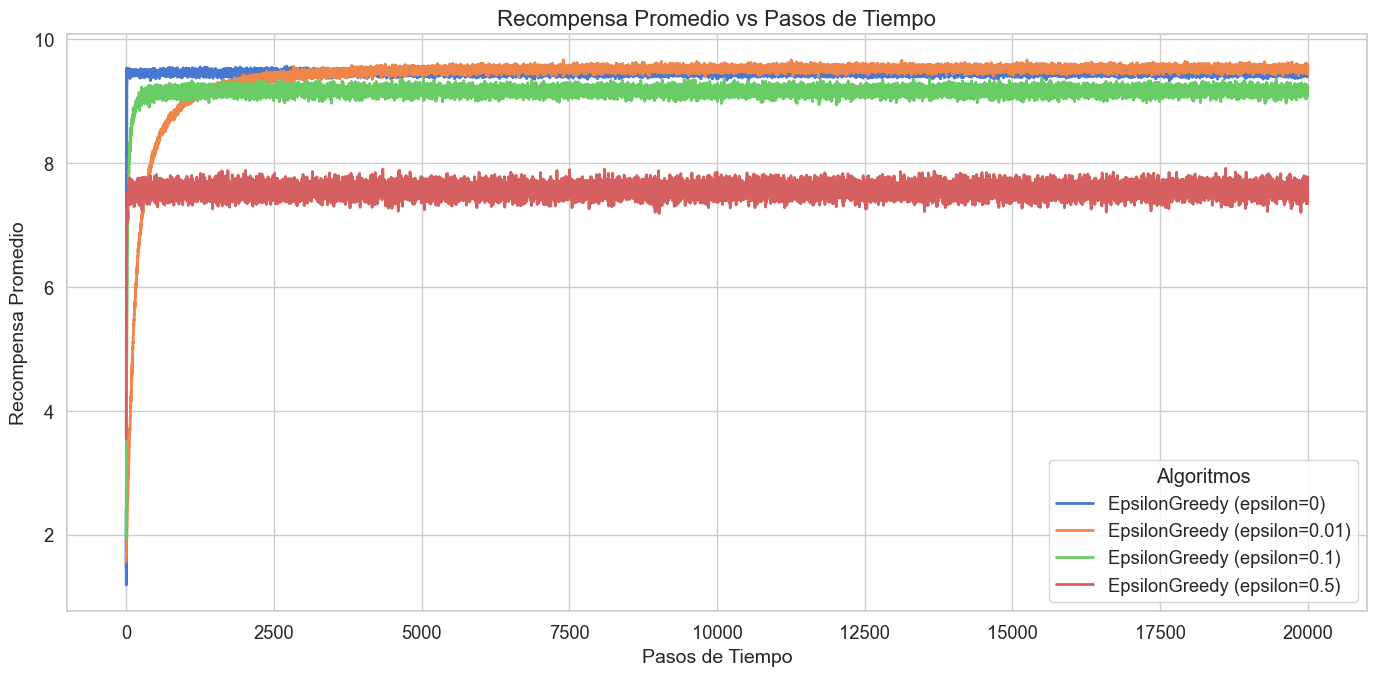

In [6]:
plot_average_rewards(STEPS, rewards_greedy, algorithms_greedy, SAVE_PLOTS_PATH)

En la gráfica de recompensa promedio vemos que hay varías configuraciones que alcanzan una recompensa en torno al valor del brazo óptimo (9.56): 0, 0.01 y 0.1, siendo algo menor la del algoritmo con epsilon=0.1 debido a un 10% de elecciones aleatorias. Esta disminución de la recompensa promedio debido a la aleatoriedad es todavía más acusada para epsilon=0.5. El número de pasos para alcanzar este valor de recompensa varía siendo dependiente de la componente exploratoria.

Destaca el valor alcanzado con epsilon=0, donde, en un gran porcentaje de las ejecuciones, el algoritmo ha sido capaz de encontrar en la primera tirada inicial de todos los brazos uno con tanta recompensa promedio como la alcanzada en más pasos por otros epsilon. En este caso se ha obtenido un buen resultado promedio con esa estrategia, pero en caso de haber seleccionado un brazo con peores recompensas, nunca podría haber cambiado la elección a lo largo de los pasos.

#### Selecciones óptimas

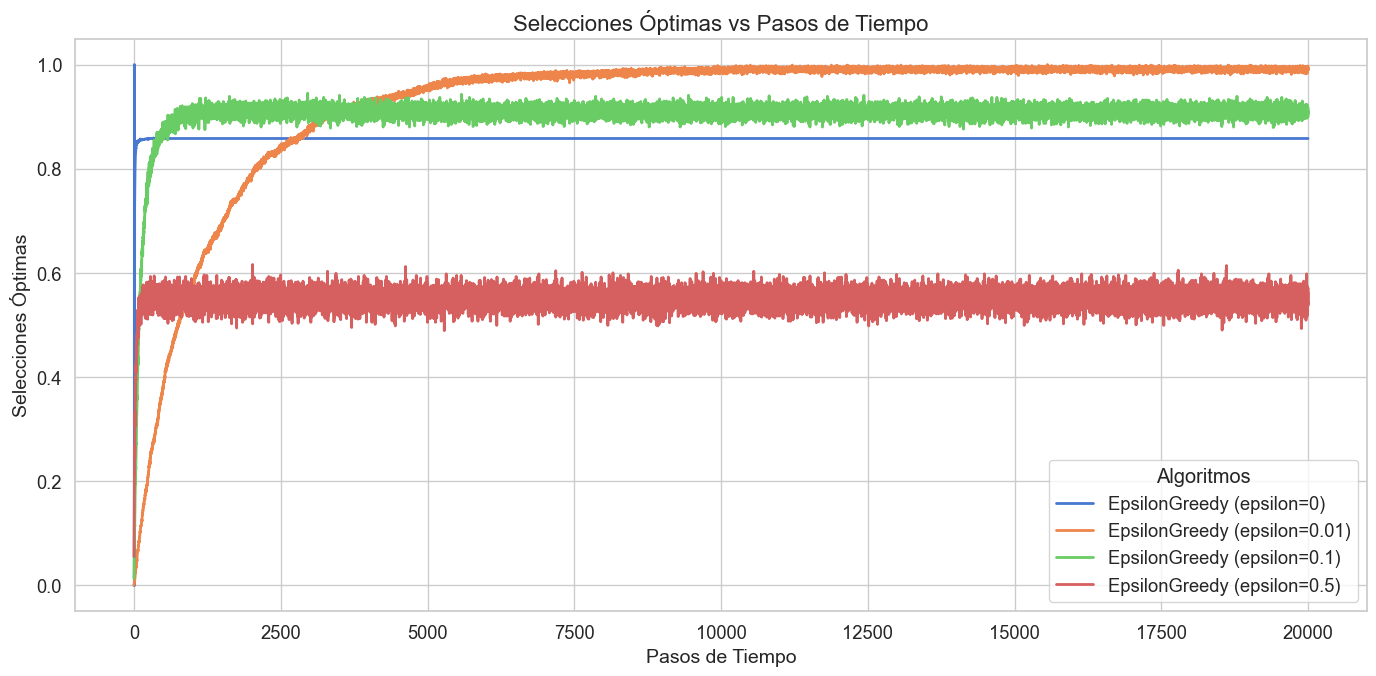

In [7]:
plot_optimal_selections(STEPS, optimal_selections_greedy, algorithms_greedy, SAVE_PLOTS_PATH)

En la gráfica de selecciones óptimas vemos nuevamente como el algoritmo con epsilon=0 es el que más rápido crece alcanzando su estado estacionario en muy pocas iteraciones. No obstante, se estanca en un valor entre 0.8 y 0.9, de esto extraemos que no ha elegido el brazo óptimo en la inicialización en todas las ejecuciones. De hecho, todos los algoritmos que presenta una componente exploratoria menos epsilon=0.5 acaban teniendo una mejor tasa de éxito. En el caso de epsilon=0.1, vemos que se estabiliza sobre 0.9, lo cual encaja con un aprendizaje del mejor brazo donde aproximadamente el 10% de error corresponde a los intentos aleatorios por la componente exploratoria. El algoritmo con epsilon=0.01 acaba estabilizándose en torno a 0.99. Para epsilon=0.5, la mitad de las selecciones se realizan de manera aleatoria por lo que el resultado obtenido es el esperado con un 55% de selecciones correctas: 50% de selecciones intentando maximizar la recompensa + el 5% correspondiente a las elecciones aleatorias (el 10% de 50%).

El aumento drástico del porcentaje de selecciones óptimas justo al inicio corresponde con la selección del brazo óptimo en el barrido inicial, que siempre se encuentra en la misma posición, la octava en este caso.

#### Arrepentimiento

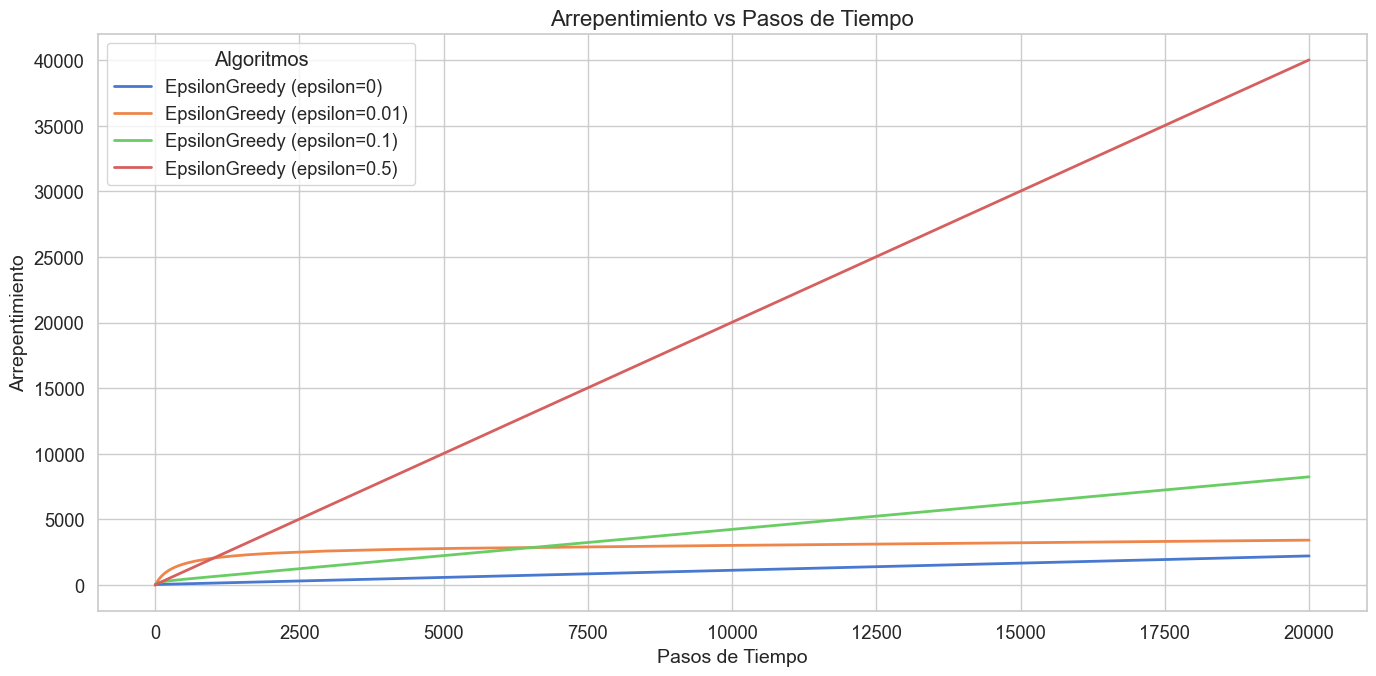

In [8]:
plot_regret(STEPS, regret_accumulated_greedy, algorithms_greedy, SAVE_PLOTS_PATH)

En la gráfica de arrepentimiento acumulado, apreciamos como este aumenta a distintas velocidades dependiendo del valor epsilon. El algoritmo con epsilon=0 comienza y termina con la menor tasa de arrepentimiento acumulado por la decisión de un brazo con un arrepentimiento bajo en la mayoría de las ejecuciones. Siguiendo con lo visto en las gráficas anteriores, el arrepentimiento para epsilon=0.5 asciende de forma lineal mientras que para epsilon=0.01 y epsilon=0.1 el aumento es más controlado debido a su menor exploración. Al avanzar los pasos, vemos como el arrepentimiento acumulado de epsilon=0.1 supera al de eplison=0.01. De manera similar, se observa como la tendencia de epsilon=0.1 y epsilon=0.01 muestra como, al algoritmo con epsilon=0 no elegir en todas las ejecuciones el brazo óptimo, la variante epsilon=0.01 terminará siendo la que menos arrepentimiento acumule si continúan avanzado los pasos.

#### Estadísticas por brazo

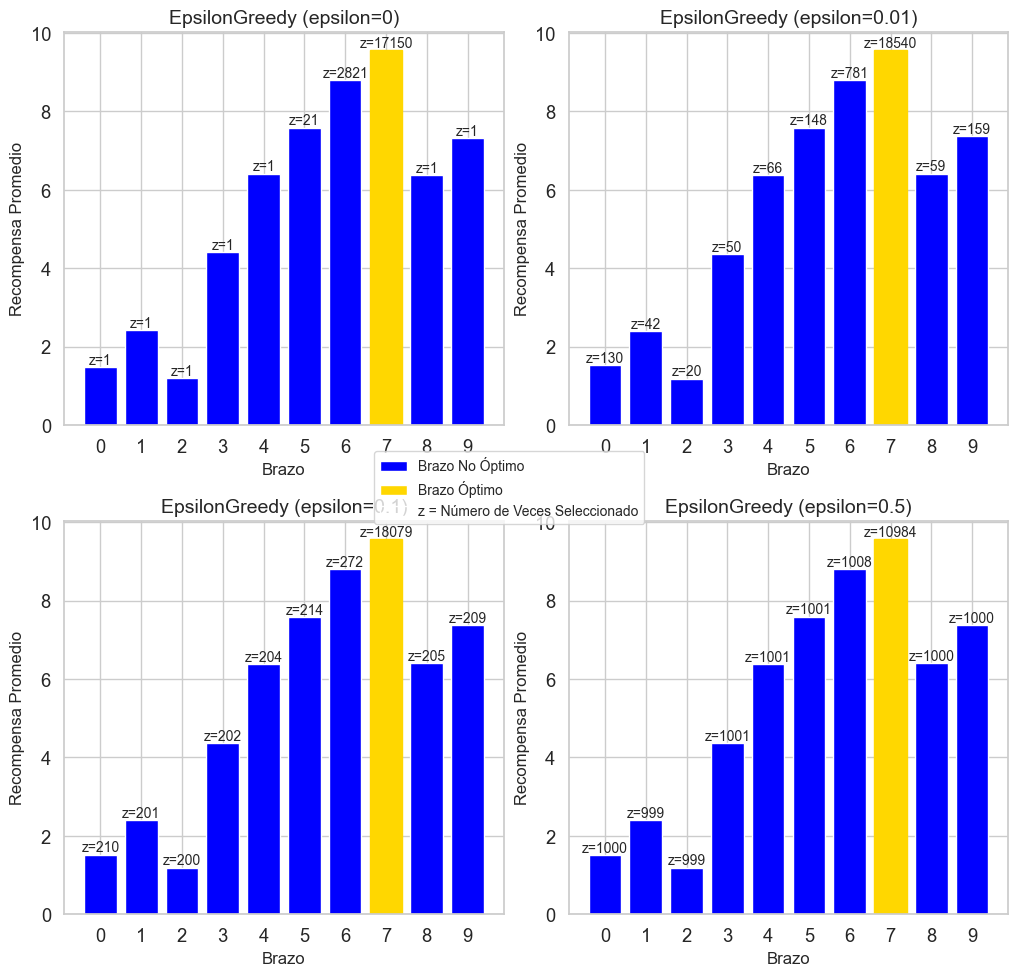

In [9]:
plot_arm_statistics(arm_stats_greedy, algorithms_greedy, SAVE_PLOTS_PATH)

Con estos diagramas de estadísticas por brazo, se puede confirmar que el algoritmo con epsilon=0 en la gran mayoría de sus ejecuciones ha elegido el más óptimo o el segundo más óptimo, de ahí los buenos resultados obtenidos pese a la nula exploración. El resto de algoritmos también toman el brazo óptimo el que más, ocurriendo que cuanto menor es su valor epsilon más veces han elegido el mejor brazo debido a la larga cantidad de pasos donde explotar el brazo con mejor promedio.

## Conclusiones

En este notebook, se ha trabajado el problema del bandido de k-brazos con el algoritmo $\epsilon$-Greedy y brazos con distribución normal. Se puede concluir que, a mayor sea el número de pasos en los que se planee ejecutar el algoritmo, más beneficio se obtendrá de usar una tasa de exploración menor. De esa forma, aunque pueda tardar más en encontrar el brazo óptimo, el resto de pasos serán más eficientes que en algoritmos con un epsilon mayor. Apoyándonos es esta conclusión, podemos intuir que un algoritmo con epsilon-decaimiento, eligiendo una tasa correcta, podría aprovechar al máximo esta idea de encontrar el brazo óptimo y después perder el mínimo de recompensa con la exploración en el resto de pasos.